SHANKAR K

GRIP SPARK FOUNDATION _ MAY-21

TASK 6 - Prediction using Decision tree algorithm

DATA SCIENCE AND BUSINESS ANALYTICS INTERNSHIP

In [1]:
#importing libraries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns
sns.set()

In [3]:
#importing the dataset
dataset = pd.read_csv('/content/Iris (1).csv')
dataset.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
dataset.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Handling missing data

In [5]:
dataset.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

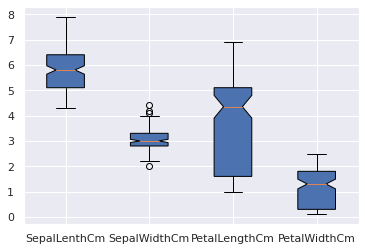

In [7]:
SepalLenthCm = dataset['SepalLengthCm']
SepalWidthCm = dataset['SepalWidthCm']
PetalLengthCm = dataset['PetalLengthCm']
PetalWidthCm = dataset['PetalWidthCm']
columns=[SepalLenthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm]
fig,ax = plt.subplots()
ax.boxplot(columns,notch=True,patch_artist=True)
plt.xticks([1,2,3,4],['SepalLenthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm'])
plt.show()

In [10]:
Q1 = dataset['SepalWidthCm'].quantile(0.25)
Q3 = dataset['SepalWidthCm'].quantile(0.75)
IQR =Q3-Q1
ur = Q3+1.5*IQR
lr = Q1-1.5*IQR
samp= dataset.index[dataset['SepalWidthCm']>ur]
samp.append(dataset.index[dataset['SepalWidthCm']<lr])
data = dataset.drop(samp)
data.reset_index(drop=True)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
142,146,6.7,3.0,5.2,2.3,Iris-virginica
143,147,6.3,2.5,5.0,1.9,Iris-virginica
144,148,6.5,3.0,5.2,2.0,Iris-virginica
145,149,6.2,3.4,5.4,2.3,Iris-virginica


Split the dataset for training and testing

In [12]:
df = data.copy()
x = df.iloc[:,1:5]
y = df.iloc[:,-1]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state = 42)

In [13]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score
clf = DecisionTreeClassifier()
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)


In [14]:
accuracy = accuracy_score(y_test,y_pred)
accuracy*100

97.2972972972973

In [15]:
data= {'y_Actual':y_test,
       'y_Predicted':y_pred
       }
df= pd.DataFrame(data)
df.reset_index(inplace=True,drop = True)
df.head()

,y_Actual,y_Predicted
0,Iris-virginica,Iris-virginica
1,Iris-versicolor,Iris-versicolor
2,Iris-virginica,Iris-virginica
3,Iris-setosa,Iris-setosa
4,Iris-virginica,Iris-virginica


In [16]:
# Install required libraries
!pip install pydotplus
!apt-get install graphviz -y

Reading package lists... Done
Building dependency tree       
Reading state information... Done
graphviz is already the newest version (2.40.1-2).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


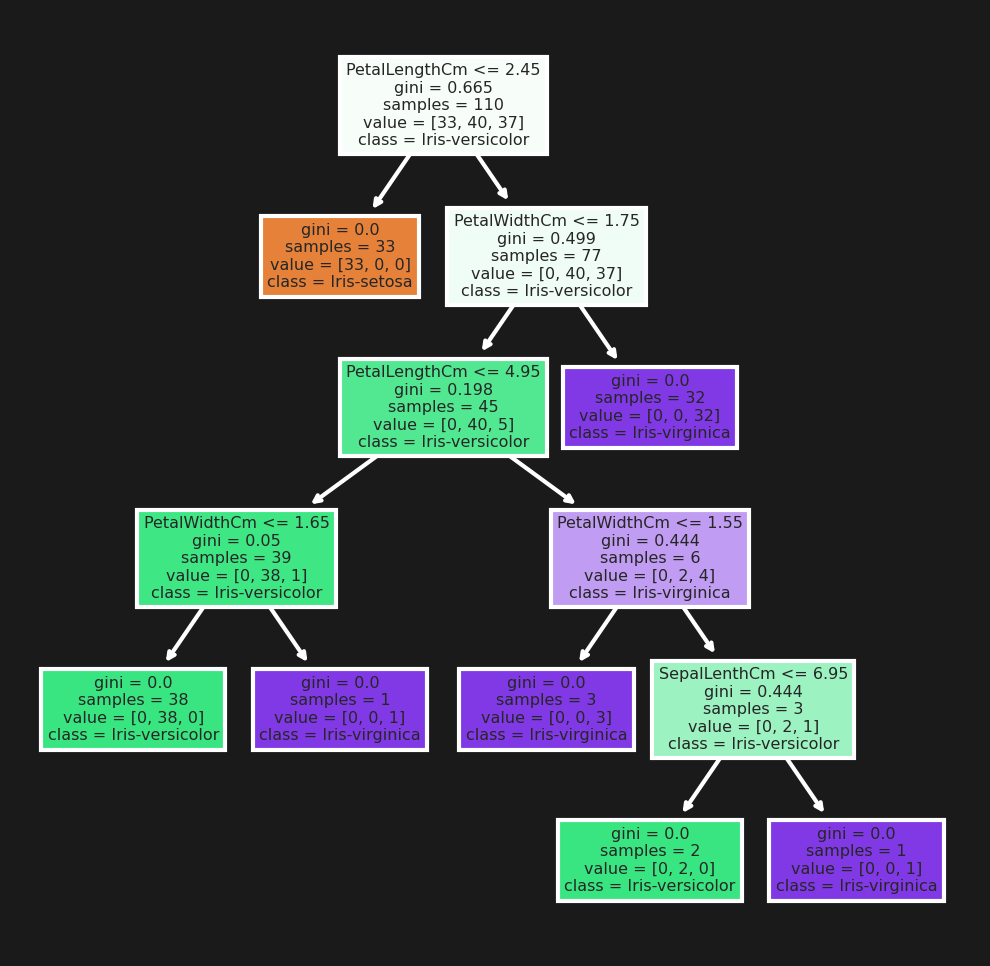

In [22]:
# Import necessary libraries for graph viz
from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus
from sklearn import tree

# Visualize the graph
feature_names = ['SepalLenthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
class_names=['Iris-setosa','Iris-versicolor','Iris-virginica']
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(4,4),dpi=300,facecolor = 'k')
tree.plot_tree(clf,feature_names=feature_names,class_names=class_names,filled=tree);
fig.savefig('IrisTree.png')